In [1]:
# ライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# PATHの設定
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')

In [2]:
df.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,Price_Per_Range,Energy_Rating
0,Audi,e-tron 50 quattro,6.8,190,280,231,450,Yes,AWD,Type 2 CCS,SUV,E,5,67358,240.56,High Consumption
1,Tesla,Cybertruck Dual Motor,5.0,190,460,261,710,Yes,AWD,Type 2 CCS,Pickup,N,6,55000,119.57,High Consumption
2,Nissan,Ariya 87kWh,7.6,160,440,198,520,Yes,FWD,Type 2 CCS,Hatchback,C,5,50000,113.64,Average
3,Porsche,Taycan 4S,4.0,250,365,195,730,Yes,AWD,Type 2 CCS,Sedan,F,4,102945,282.04,Average
4,Audi,e-tron Sportback 55 quattro,5.7,200,380,228,610,Yes,AWD,Type 2 CCS,SUV,E,5,81639,214.84,High Consumption


In [3]:
#データサイズ確認
print('データの大きさ:', df.shape)

データの大きさ: (103, 16)


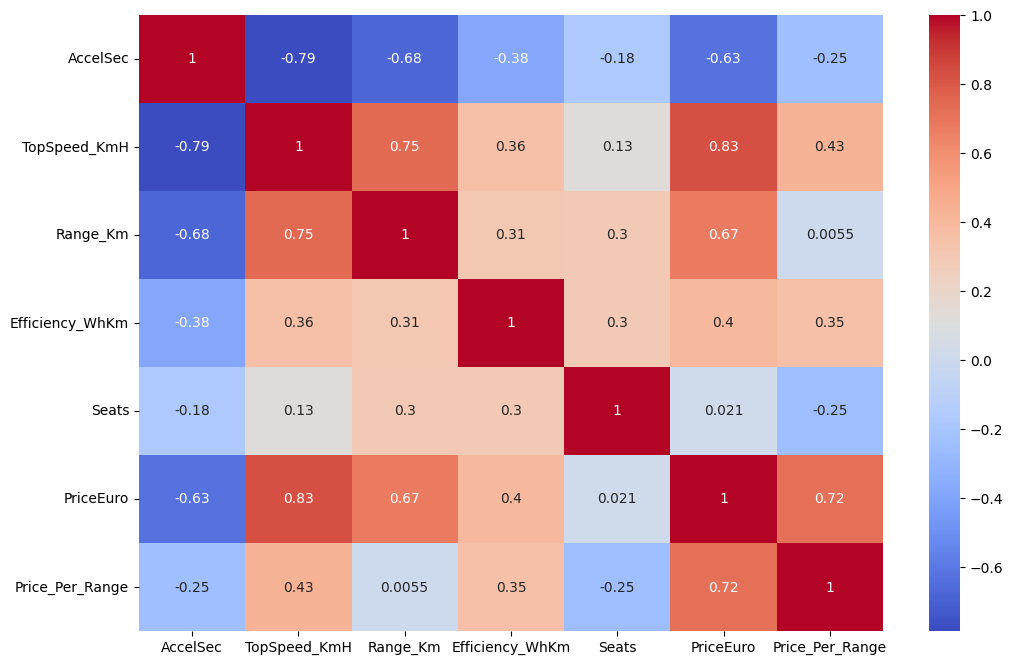

In [4]:
#相関関係を確認：ヒートマップ
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

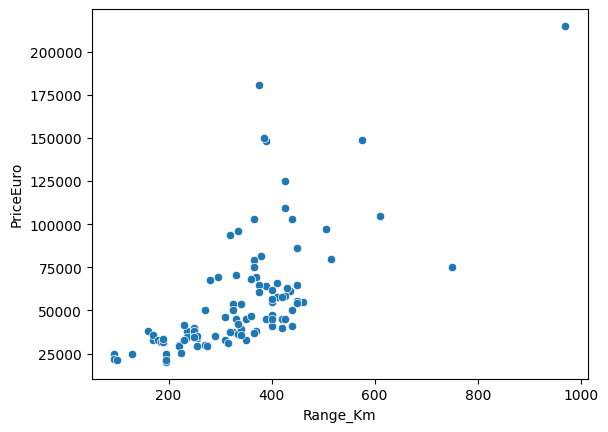

In [5]:
#価格とバッテリー容量の関係は？
sns.scatterplot(x=df["Range_Km"], y=df["PriceEuro"])
plt.show()

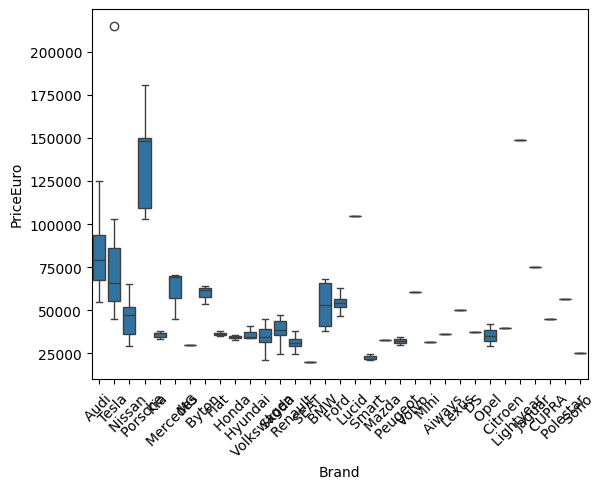

In [6]:
#ブランドと価格の関係
sns.boxplot(x=df["Brand"], y=df["PriceEuro"])
plt.xticks(rotation=45)
plt.show()

In [11]:
#前処理：103レコードしかないので不要なカラムを削除する
#Price_Per_Range 理由：  PriceEuroを使って作られている（＝データリーク）
df = df.drop("Price_Per_Range", axis=1)

#Model 理由：ほぼユニーク値（= ノイズ）
df = df.drop("Model", axis=1)

#Brand 理由：33社あるから
df = df.drop("Brand", axis=1)

KeyError: "['Price_Per_Range'] not found in axis"

In [16]:
#最適構成
features = [
    "AccelSec",
    "TopSpeed_KmH",
    "Range_Km",
    "Efficiency_WhKm"
]

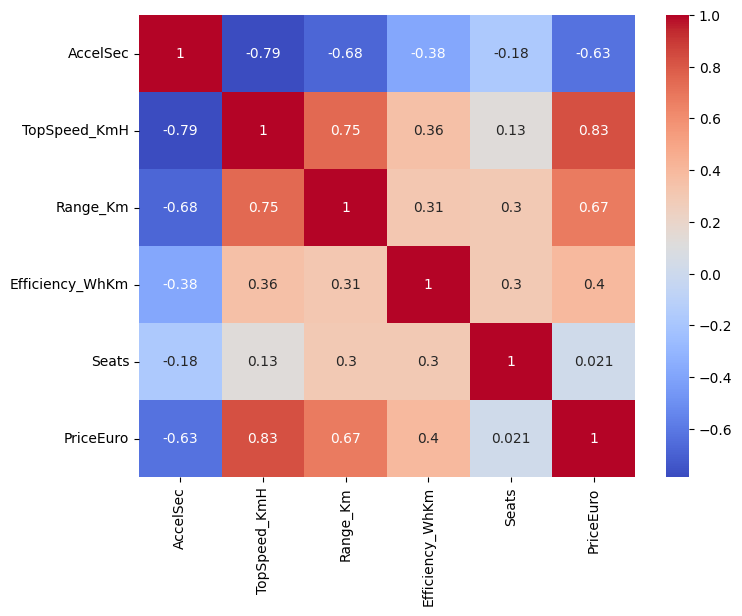

In [17]:
#カラムを削ったので再度相関ヒートマップ
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

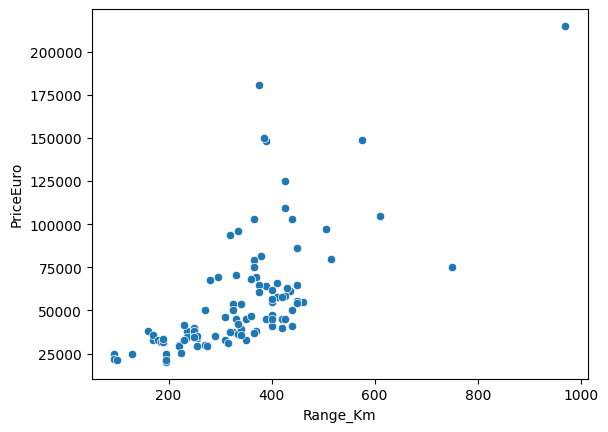

In [18]:
#価格 vs 各特徴量（散布図）
sns.scatterplot(x="Range_Km", y="PriceEuro", data=df)
plt.show()

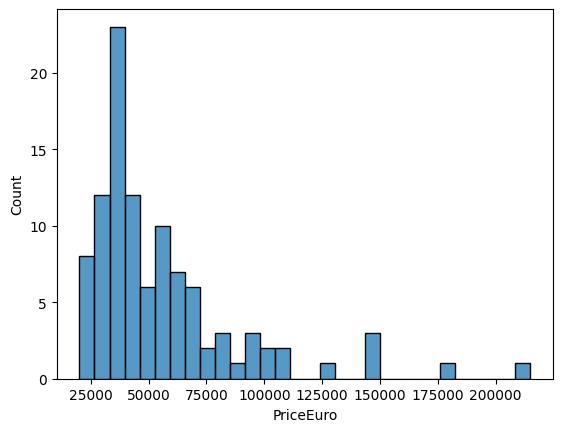

In [19]:
#分布
sns.histplot(df["PriceEuro"], bins=30)
plt.show()

In [45]:
# 特徴量
import pandas as pd
import numpy as np

# =========================
# ① 読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'

#df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')

# =========================
# ② コピー
# =========================
df_model = df.copy()

# =========================
# ③ 特徴量作成（df_modelに統一）
# =========================
df_model["Power_Index"] = df_model["TopSpeed_KmH"] / df_model["AccelSec"]
df_model["Efficiency_Range"] = df_model["Range_Km"] / df_model["Efficiency_WhKm"]

# =========================
# ④ Brandエンコード
# =========================
df_model = pd.get_dummies(df_model, columns=["Brand"], drop_first=True)

# =========================
# ⑤ 特徴量
# =========================
features = [col for col in df_model.columns if col != "PriceEuro"]

X = df_model[features]
y = df_model["PriceEuro"]

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# 数値だけ自動抽出（ここがポイント）
X = df_model.select_dtypes(include=[np.number]).drop("PriceEuro", axis=1, errors="ignore")
y = df_model["PriceEuro"]

# 分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# モデル
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# 学習
model.fit(X_train, np.log1p(y_train))

# 予測
pred = model.predict(X_test)
pred = np.expm1(pred)

# 評価
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)


RMSE: 16056.034557425317


In [50]:
# =========================
#複数モデルを自動で比較して一番RMSEが良いモデルを選ぶ
#ライブラリ
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# =========================
# 特徴量
# =========================
features = [
    "AccelSec",
    "TopSpeed_KmH",
    "Range_Km",
    "Efficiency_WhKm"
]

X = df[features]
y = df["PriceEuro"]

# =========================
# モデル定義
# =========================
models = {
    "Ridge": Ridge(alpha=1.0),

    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        min_child_samples=5,
        random_state=42
    )
}

# =========================
# KFold
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# =========================
# モデル比較
# =========================
for name, model in models.items():
    rmse_list = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # log変換
        model.fit(X_train, np.log1p(y_train))

        pred = model.predict(X_val)
        pred = np.expm1(pred)

        rmse = np.sqrt(mean_squared_error(y_val, pred))
        rmse_list.append(rmse)

    results[name] = np.mean(rmse_list)

# =========================
# 結果表示
# =========================
for name, score in results.items():
    print(f"{name}: RMSE = {score:.2f}")

# =========================
# ベストモデル
# =========================
best_model = min(results, key=results.get)
print("\n🏆 Best Model:", best_model)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 82, number of used features: 4
[LightGBM] [Info] Start training from score 10.789125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf